# B_S2.2 — Metric Separability Analysis (ROC / AUC)

For each of the 75 observed metrics from S2, evaluate how well it separates
**no-relationship** (true_null) from **relationship** cases.

Three binary comparisons:
1. `true_null` vs `mean_only` — can the metric detect mean-shift relationships?
2. `true_null` vs `variance_only` — can the metric detect spread-change relationships?
3. `true_null` vs `mean+variance` — can the metric detect combined relationships?

Metrics: ROC curve, AUC, and stratification by SNR.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

## Load Data

In [ ]:
S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

# Load metrics
metrics_df = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

# Load case labels
cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_all = pd.concat([cases_main, cases_null], ignore_index=True)

# Merge labels into metrics
label_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category', 'source']
df = metrics_df.merge(cases_all[label_cols], on=['case_id', 'source'], how='left')

# Identify metric columns
non_metric = {'case_id', 'source', 'n_valid', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category'}
metric_cols = sorted([c for c in df.columns if c not in non_metric])

print(f'Total cases: {len(df):,}')
print(f'Metric columns: {len(metric_cols)}')
print(f'x_distribution groups: {df["x_distribution"].nunique()}')
print()
print(df['category'].value_counts())

## Compute AUC: Each Metric × Each Comparison

In [3]:
null_df = df[df['category'] == 'true_null']

comparisons = {
    'null_vs_mean_only':     df[df['category'] == 'mean_only'],
    'null_vs_variance_only': df[df['category'] == 'variance_only'],
    'null_vs_mean+variance': df[df['category'] == 'mean+variance'],
}

auc_results = []

for comp_name, signal_df in comparisons.items():
    subset = pd.concat([null_df, signal_df], ignore_index=True)
    y_true = (subset['category'] != 'true_null').astype(int).values

    for m in metric_cols:
        vals = subset[m].values
        mask = np.isfinite(vals)
        if mask.sum() < 10:
            continue
        v = vals[mask]
        yt = y_true[mask]
        if len(np.unique(yt)) < 2:
            continue

        auc = roc_auc_score(yt, np.abs(v))
        auc = max(auc, 1 - auc)  # direction-agnostic

        auc_results.append({
            'metric': m,
            'comparison': comp_name,
            'auc': auc,
            'n_null': int((yt == 0).sum()),
            'n_signal': int((yt == 1).sum()),
        })

auc_df = pd.DataFrame(auc_results)
print(f'Computed {len(auc_df)} AUC values ({len(metric_cols)} metrics × {len(comparisons)} comparisons)')

Computed 225 AUC values (75 metrics × 3 comparisons)


## AUC Summary Table

In [4]:
auc_pivot = auc_df.pivot(index='metric', columns='comparison', values='auc')
auc_pivot['mean_auc'] = auc_pivot.mean(axis=1)
auc_pivot = auc_pivot.sort_values('mean_auc', ascending=False)

print('Top 20 metrics by mean AUC across all comparisons:')
print(auc_pivot.head(20).to_string(float_format='{:.3f}'.format))
print()
print('Bottom 10 metrics:')
print(auc_pivot.tail(10).to_string(float_format='{:.3f}'.format))

Top 20 metrics by mean AUC across all comparisons:
comparison                                              null_vs_mean+variance  null_vs_mean_only  null_vs_variance_only  mean_auc
metric                                                                                                                           
distance_correlation                                                    1.000              0.986                  0.998     0.995
MIC                                                                     0.993              0.964                  0.967     0.975
distance_covariance                                                     0.968              0.936                  0.988     0.964
MEV                                                                     0.993              0.964                  0.928     0.962
equal_count_distribution_ks_distance                                    0.990              0.953                  0.917     0.953
equal_width_distribution_ks_distance   

## Fig 1: AUC Heatmap (All Metrics × All Comparisons)

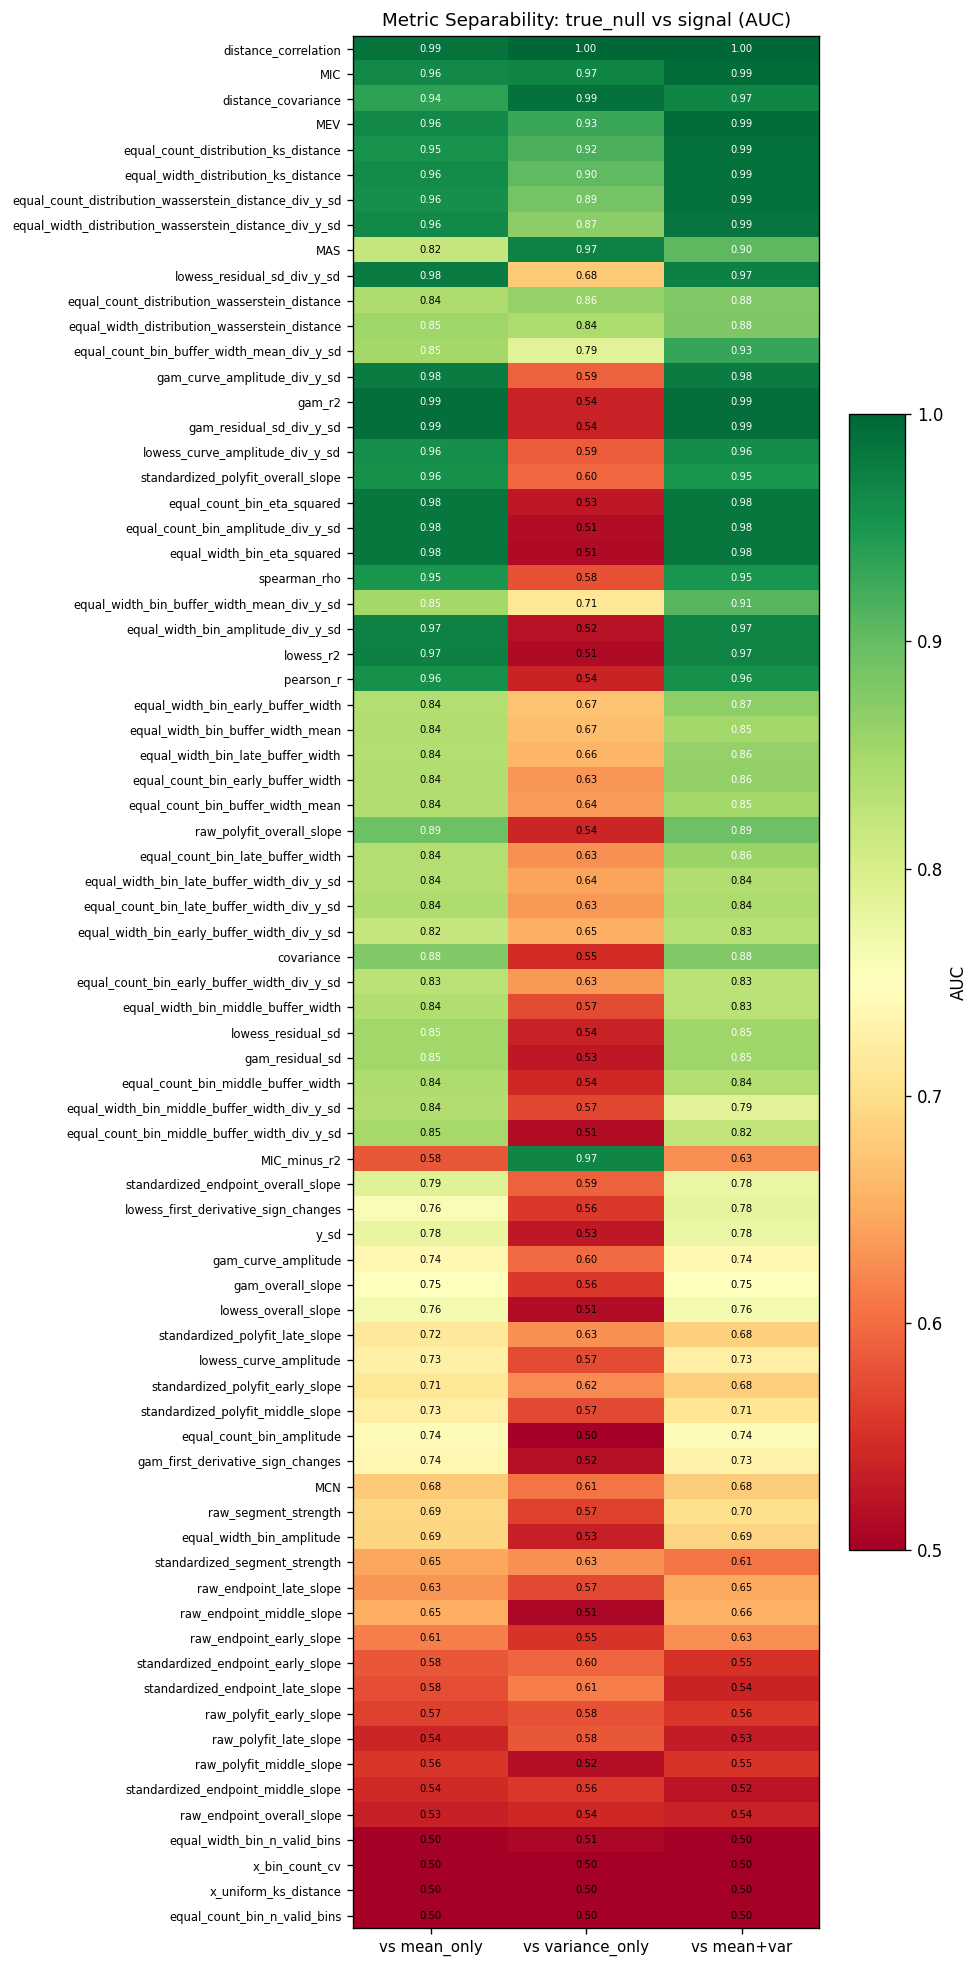

Saved → output/S2.2/fig1_auc_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(8, max(14, len(auc_pivot) * 0.22)))

plot_cols = ['null_vs_mean_only', 'null_vs_variance_only', 'null_vs_mean+variance']
data = auc_pivot[plot_cols].values

im = ax.imshow(data, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_yticks(range(len(auc_pivot)))
ax.set_yticklabels(auc_pivot.index, fontsize=7)
ax.set_xticks(range(len(plot_cols)))
ax.set_xticklabels(['vs mean_only', 'vs variance_only', 'vs mean+var'], fontsize=9)

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        color = 'white' if data[i, j] > 0.85 else 'black'
        ax.text(j, i, f'{data[i,j]:.2f}', ha='center', va='center', fontsize=6, color=color)

plt.colorbar(im, ax=ax, label='AUC', shrink=0.6)
ax.set_title('Metric Separability: true_null vs signal (AUC)', fontsize=11)
plt.tight_layout()

VIZ_DIR = Path('output/S2.2'); VIZ_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(VIZ_DIR / 'fig1_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig1_auc_heatmap.png"}')

## Fig 2: Top-10 Metrics ROC Curves

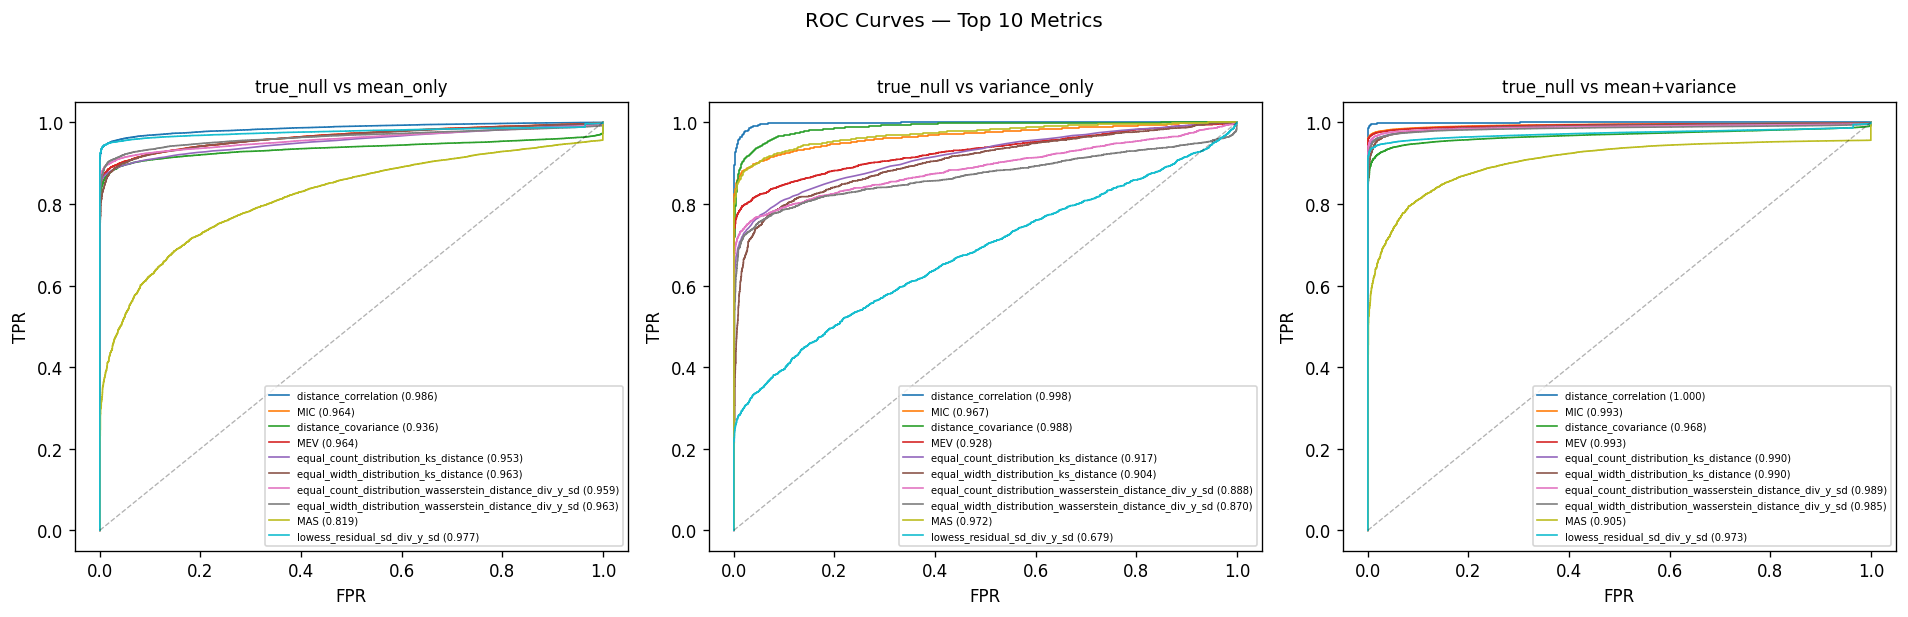

Saved → output/S2.2/fig2_roc_top10.png


In [6]:
top10 = auc_pivot.head(10).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
comp_labels = {
    'null_vs_mean_only': 'true_null vs mean_only',
    'null_vs_variance_only': 'true_null vs variance_only',
    'null_vs_mean+variance': 'true_null vs mean+variance',
}

for ax, (comp_name, signal_df) in zip(axes, comparisons.items()):
    subset = pd.concat([null_df, signal_df], ignore_index=True)
    y_true = (subset['category'] != 'true_null').astype(int).values

    for m in top10:
        vals = np.abs(subset[m].values)
        mask = np.isfinite(vals)
        if mask.sum() < 10:
            continue
        auc = roc_auc_score(y_true[mask], vals[mask])
        if auc < 0.5:
            vals = -vals
            auc = 1 - auc
        fpr, tpr, _ = roc_curve(y_true[mask], vals[mask])
        ax.plot(fpr, tpr, label=f'{m} ({auc:.3f})', linewidth=1)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=0.8)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(comp_labels[comp_name], fontsize=10)
    ax.legend(fontsize=6, loc='lower right')

plt.suptitle('ROC Curves — Top 10 Metrics', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2_roc_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig2_roc_top10.png"}')

## Fig 3: AUC by SNR (Top Metrics, Detection Boundary)

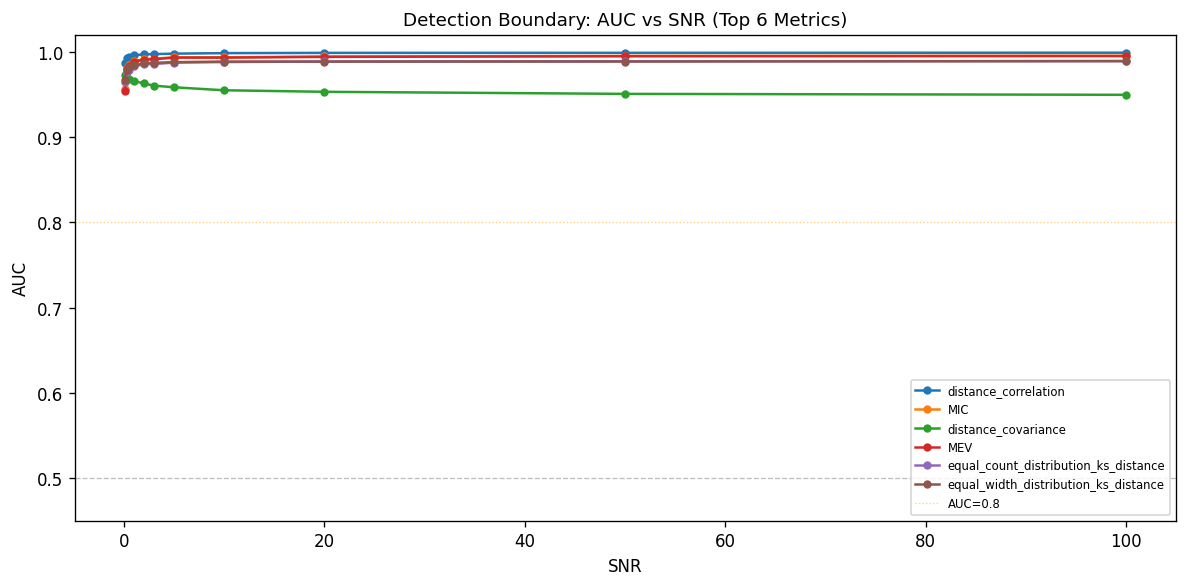

Saved → output/S2.2/fig3_auc_by_snr.png


In [7]:
top6 = auc_pivot.head(6).index.tolist()

# Only use mean_only + mean+variance (they have SNR variation)
signal_cats = ['mean_only', 'mean+variance']
signal_all = df[df['category'].isin(signal_cats)]
snr_levels = sorted(signal_all['snr'].unique())

snr_auc = []
for snr_val in snr_levels:
    sig_snr = signal_all[signal_all['snr'] == snr_val]
    subset = pd.concat([null_df, sig_snr], ignore_index=True)
    y_true = (subset['category'] != 'true_null').astype(int).values

    for m in top6:
        vals = np.abs(subset[m].values)
        mask = np.isfinite(vals)
        if mask.sum() < 10 or len(np.unique(y_true[mask])) < 2:
            continue
        auc = roc_auc_score(y_true[mask], vals[mask])
        auc = max(auc, 1 - auc)
        snr_auc.append({'metric': m, 'snr': snr_val, 'auc': auc})

snr_auc_df = pd.DataFrame(snr_auc)

fig, ax = plt.subplots(figsize=(10, 5))
for m in top6:
    sub = snr_auc_df[snr_auc_df['metric'] == m].sort_values('snr')
    ax.plot(sub['snr'], sub['auc'], 'o-', label=m, markersize=4, linewidth=1.5)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(0.8, color='orange', linestyle=':', alpha=0.5, linewidth=0.8, label='AUC=0.8')
ax.set_xlabel('SNR')
ax.set_ylabel('AUC')
ax.set_title('Detection Boundary: AUC vs SNR (Top 6 Metrics)', fontsize=11)
ax.legend(fontsize=7, loc='lower right')
ax.set_ylim(0.45, 1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig3_auc_by_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig3_auc_by_snr.png"}')

## Fig 4: Variance-Only Detection — Which Metrics Work?

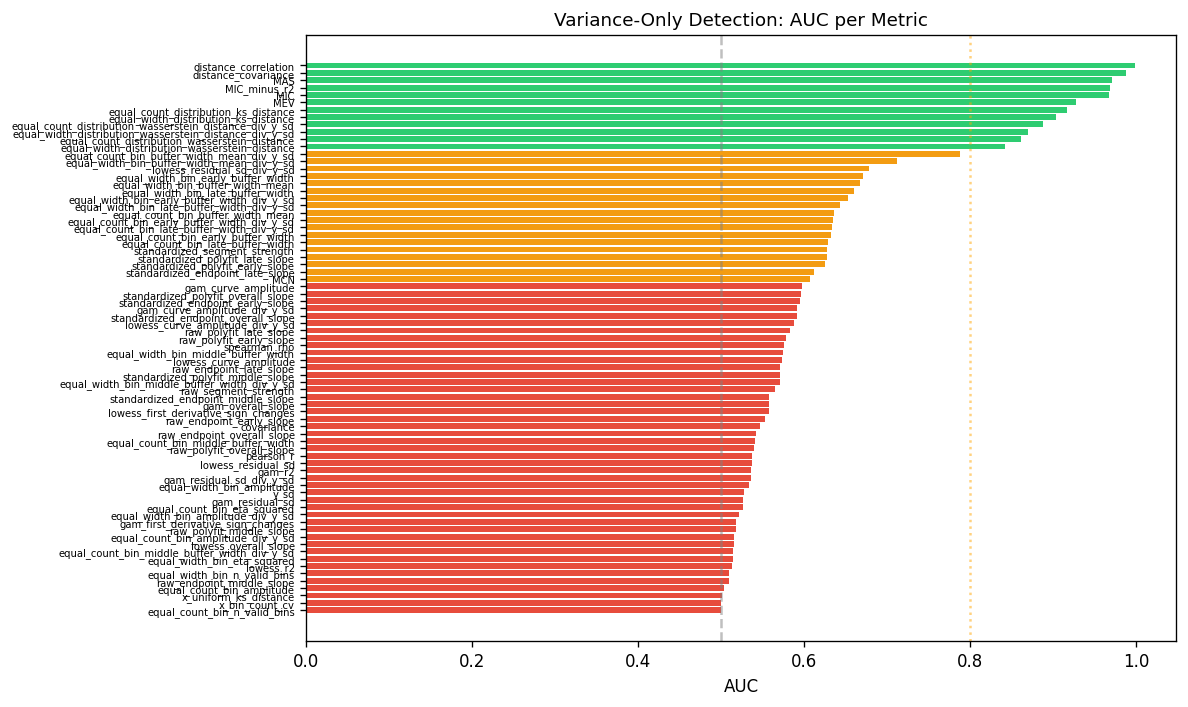

Saved → output/S2.2/fig4_variance_only_auc.png

Top 10 for variance_only detection:
                                                metric   auc
                                  distance_correlation 0.998
                                   distance_covariance 0.988
                                                   MAS 0.972
                                          MIC_minus_r2 0.968
                                                   MIC 0.967
                                                   MEV 0.928
                  equal_count_distribution_ks_distance 0.917
                  equal_width_distribution_ks_distance 0.904
equal_count_distribution_wasserstein_distance_div_y_sd 0.888
equal_width_distribution_wasserstein_distance_div_y_sd 0.870


In [8]:
# Variance-only is the hardest to detect — most mean-based metrics fail
var_auc = auc_df[auc_df['comparison'] == 'null_vs_variance_only'].copy()
var_auc = var_auc.sort_values('auc', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if a > 0.8 else '#f39c12' if a > 0.6 else '#e74c3c' for a in var_auc['auc']]
ax.barh(range(len(var_auc)), var_auc['auc'].values, color=colors)
ax.set_yticks(range(len(var_auc)))
ax.set_yticklabels(var_auc['metric'].values, fontsize=6)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0.8, color='orange', linestyle=':', alpha=0.5)
ax.set_xlabel('AUC')
ax.set_title('Variance-Only Detection: AUC per Metric', fontsize=11)
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig4_variance_only_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig4_variance_only_auc.png"}')

print('\nTop 10 for variance_only detection:')
print(var_auc.head(10)[['metric', 'auc']].to_string(index=False, float_format='{:.3f}'.format))

## Fig 5: MINE/LOWESS vs Core Metrics — Direct Comparison

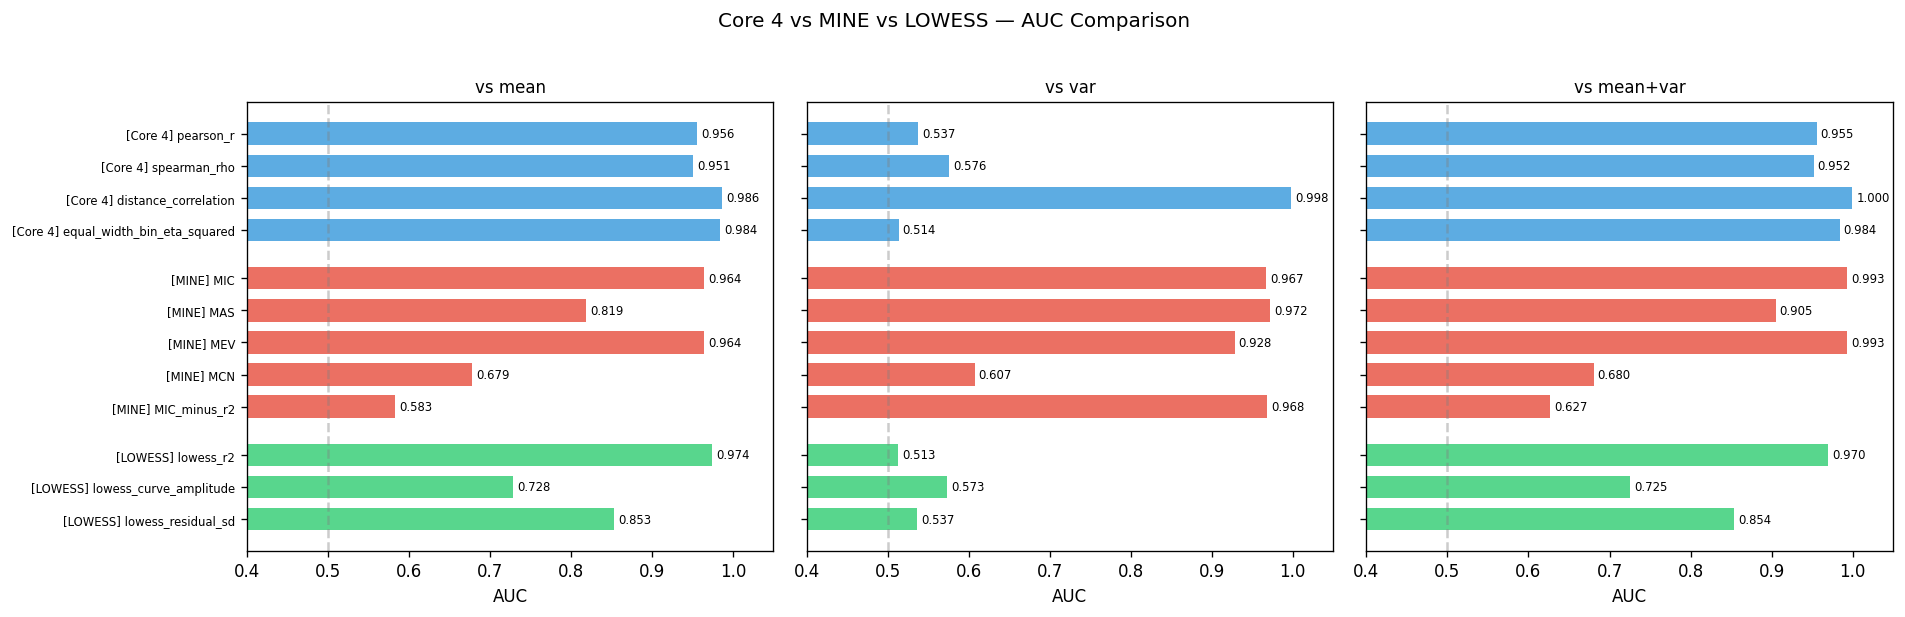

Saved → output/S2.2/fig5_core_vs_mine_lowess.png


In [9]:
core_metrics = ['pearson_r', 'spearman_rho', 'distance_correlation', 'equal_width_bin_eta_squared']
mine_metrics = ['MIC', 'MAS', 'MEV', 'MCN', 'MIC_minus_r2']
lowess_metrics = ['lowess_r2', 'lowess_curve_amplitude', 'lowess_residual_sd']

groups = {
    'Core 4': core_metrics,
    'MINE': mine_metrics,
    'LOWESS': lowess_metrics,
}

comp_order = ['null_vs_mean_only', 'null_vs_variance_only', 'null_vs_mean+variance']
comp_short = {'null_vs_mean_only': 'vs mean', 'null_vs_variance_only': 'vs var', 'null_vs_mean+variance': 'vs mean+var'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, comp in zip(axes, comp_order):
    comp_auc = auc_df[auc_df['comparison'] == comp].set_index('metric')['auc']

    y_pos = 0
    yticks, ylabels, ycolors = [], [], []
    group_colors = {'Core 4': '#3498db', 'MINE': '#e74c3c', 'LOWESS': '#2ecc71'}

    for gname, gmetrics in groups.items():
        for m in gmetrics:
            if m in comp_auc.index:
                auc_val = comp_auc[m]
                ax.barh(y_pos, auc_val, color=group_colors[gname], alpha=0.8, height=0.7)
                ax.text(auc_val + 0.005, y_pos, f'{auc_val:.3f}', va='center', fontsize=7)
                yticks.append(y_pos)
                ylabels.append(f'[{gname}] {m}')
                y_pos += 1
        y_pos += 0.5  # gap between groups

    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=7)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlim(0.4, 1.05)
    ax.set_xlabel('AUC')
    ax.set_title(comp_short[comp], fontsize=10)
    ax.invert_yaxis()

plt.suptitle('Core 4 vs MINE vs LOWESS — AUC Comparison', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_core_vs_mine_lowess.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig5_core_vs_mine_lowess.png"}')

## Summary

In [ ]:
print('=== Metric Separability Summary ===')
print()
for comp in comp_order:
    comp_auc = auc_df[auc_df['comparison'] == comp].sort_values('auc', ascending=False)
    top3 = comp_auc.head(3)
    print(f'{comp_short[comp]}:')
    for _, row in top3.iterrows():
        print(f'  {row["metric"]:45s}  AUC = {row["auc"]:.3f}')
    print()

print('=== Overall Top 10 (mean AUC across 3 comparisons) ===')
print(auc_pivot[['null_vs_mean_only', 'null_vs_variance_only', 'null_vs_mean+variance', 'mean_auc']].head(10).to_string(float_format='{:.3f}'.format))

# Save results
auc_pivot.to_csv(VIZ_DIR / 'auc_summary.csv', float_format='%.4f')
print(f'\nSaved → {VIZ_DIR / "auc_summary.csv"}')